<a href="https://colab.research.google.com/github/brunokobi/computacao_natural/blob/main/exercicio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 37.1 MB/s eta 0:00:00


In [ ]:
!pip install deap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 5.6 MB/s eta 0:00:00



Execução 1/30

Log da evolução (seed=42):
Geração   0 | Média fitness: 0.2181 | Máx fitness: 0.9333
Geração  10 | Média fitness: 0.9121 | Máx fitness: 0.9333
Geração  20 | Média fitness: 0.9242 | Máx fitness: 0.9667
Geração  30 | Média fitness: 0.9623 | Máx fitness: 0.9667
Geração  40 | Média fitness: 0.9590 | Máx fitness: 0.9667
Geração  50 | Média fitness: 0.9626 | Máx fitness: 0.9667
Geração  60 | Média fitness: 0.9574 | Máx fitness: 0.9667
Geração  70 | Média fitness: 0.9631 | Máx fitness: 0.9667
Geração  80 | Média fitness: 0.9604 | Máx fitness: 0.9667
Geração  90 | Média fitness: 0.9658 | Máx fitness: 0.9667
Geração  99 | Média fitness: 0.9665 | Máx fitness: 0.9667
Geração 100 | Média fitness: 0.9654 | Máx fitness: 0.9667

Execução 2/30

Log da evolução (seed=43):
Geração   0 | Média fitness: -0.0412 | Máx fitness: 0.9333
Geração  10 | Média fitness: 0.9109 | Máx fitness: 0.9333
Geração  20 | Média fitness: 0.9269 | Máx fitness: 0.9333
Geração  30 | Média fitness: 0.9576 | Máx f

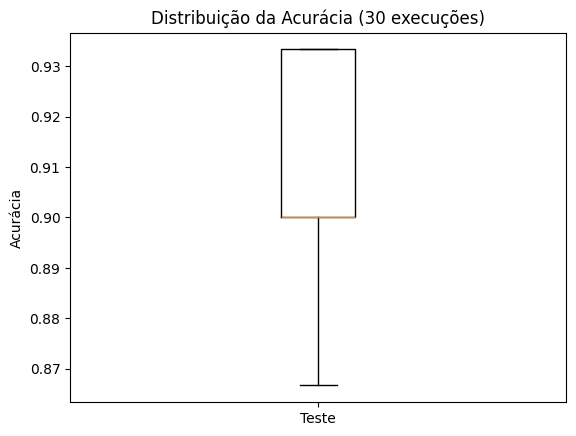

Análise:
- O log exibe a evolução do fitness médio e máximo a cada 10 gerações, permitindo acompanhar convergência.
- A função penalidade evita soluções com pesos negativos e força soma próxima de 1, garantindo interpretabilidade.
- A média de acurácia e sua variabilidade mostram a eficácia do método e a sensibilidade estocástica ao GA.


In [ ]:
# Colab notebook: Otimização de pesos por Algoritmo Genético + Lógica Fuzzy
# Versão comentada: executa 30 runs, exibe logs da evolução e estatísticas no prompt (sem gerar arquivos)
# Objetivo: usar GA (DEAP) para otimizar pesos que combinam pertinências fuzzy
# em protótipos por classe para o dataset Iris.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
import skfuzzy as fuzz
from deap import base, creator, tools, algorithms
import random, warnings, time
warnings.filterwarnings('ignore')

# ------------------------
# Parâmetros principais (configuração do experimento)
# ------------------------
# Valores escolhidos conforme recomendações comuns na literatura de EAs:
# - População entre 50-100: equilíbrio entre exploração e custo computacional
# - Gerações entre 50-200: permite convergência sem exagero
# - Crossover alto (0.6-0.9) e mutação moderada (0.1-0.3)
# - Seleção por torneio (tamanho 3) é robusta a ruído
# - N_RUNS = 30 para análise estatística (melhor/pior/média/desvio/mediana)
GA_POP = 80        # tamanho da população
GA_NGEN = 100      # número de gerações
GA_CXPB = 0.7      # probabilidade de cruzamento
GA_MUTPB = 0.2     # probabilidade de mutação
TOURN_SIZE = 3     # tamanho do torneio para seleção
N_RUNS = 30        # número de execuções independentes para análise estatística
SEED_BASE = 42     # semente base para reprodutibilidade (incrementamos por run)
PENALTY_ALPHA = 5.0  # coeficiente da função penalidade para tratar restrições

# ------------------------
# Carregar e preparar o dataset Iris
# ------------------------
# Usamos MinMaxScaler para normalizar features no intervalo [0,1]
iris = datasets.load_iris()
X, y = iris.data, iris.target
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Divisão estratificada: treino 60% / validação 20% / teste 20%
# random_state = SEED_BASE garante reprodutibilidade das divisões
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.4, stratify=y, random_state=SEED_BASE)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED_BASE)

# ------------------------
# Construção das funções de pertinência (Membership Functions - MFs)
# ------------------------
# Estratégia: para cada uma das 4 features, definimos 3 termos linguísticos
# ("low", "mid", "high") com MFs gaussianas. Centros baseados em quantis
# (15%, 50%, 85%) para acomodar distribuição dos dados; larguras (sigma)
# proporcionais ao desvio padrão da feature no conjunto de treino.
n_features, n_terms = X_train.shape[1], 3
centers, sigmas = [], []
for i in range(n_features):
    col = X_train[:, i]
    # centros em quantis para cada termo linguístico
    centers.append(np.quantile(col, [0.15, 0.5, 0.85]))
    # sigma proporcional ao spread (ajustável)
    spread = np.std(col)
    sigmas.append([spread*0.8, spread*0.6, spread*0.8])
centers, sigmas = np.array(centers), np.array(sigmas)

# Vector de pertinência: dado um vetor de features x (normalizado), retorna
# um vetor concatenado de pertinências [f1_low, f1_mid, f1_high, f2_low, ...]
def membership_vector(x):
    return np.array([
        fuzz.gaussmf(x[i], centers[i, t], sigmas[i, t])
        for i in range(n_features) for t in range(n_terms)
    ])

# Computar vetores de pertinência para todos os exemplos (treino/val/test)
M_train = np.array([membership_vector(x) for x in X_train])
M_val = np.array([membership_vector(x) for x in X_val])
M_test = np.array([membership_vector(x) for x in X_test])

# ------------------------
# Protótipos fuzzy por classe
# ------------------------
# Para representar cada classe, usamos o protótipo obtido pela média dos
# vetores de pertinência das amostras de treino daquela classe. Assim cada
# classe tem um vetor de referência no espaço fuzzy.
n_weights = n_features * n_terms
prototypes = np.array([M_train[y_train == c].mean(axis=0) for c in np.unique(y)])

# ------------------------
# Funções de predição e penalidade
# ------------------------
# predict_with_weights: calcula, para cada amostra, a similaridade com cada
# protótipo usando pesos w: sim = sum( w * (1 - |m - p|) ). A classe predita é
# aquela com maior similaridade.

def predict_with_weights(M, w):
    preds = []
    for m in M:
        sims = [np.sum(w * (1 - np.abs(m - p))) for p in prototypes]
        preds.append(np.argmax(sims))
    return np.array(preds)

# penalty: função penalidade que trata restrições do problema. Aqui queremos
# favorecer soluções com pesos não-negativos e soma igual a 1. Penalizamos a
# soma das violações (negativos absolutos + desvio da soma para 1) multiplicada
# por um coeficiente PENALTY_ALPHA.

def penalty(w):
    # soma das magnitudes de pesos negativos (se houver)
    neg_violation = np.sum(np.abs(w[w < 0]))
    # violação na soma (desejamos sum(w) == 1)
    sum_violation = abs(np.sum(w) - 1.0)
    return PENALTY_ALPHA * (neg_violation + sum_violation)

# fitness: função objetivo usada pelo GA (DEAP). Retorna a acurácia na validação
# menos a penalidade. Note que normalizamos os pesos antes de calcular acurácia
# para dar estabilidade; contudo a penalidade considera se houve pesos negativos
# e o quanto a soma difere de 1.
def fitness(ind):
    w = np.array(ind)
    # normalização para evitar divisão por zero — mantém relação entre genes
    w = w / w.sum() if w.sum() != 0 else np.ones_like(w) / len(w)
    acc = accuracy_score(y_val, predict_with_weights(M_val, w))
    return (acc - penalty(w),)

# ------------------------
# Construção do toolbox DEAP por execução
# ------------------------
# Criamos toolbox fresh para cada run para garantir sementes diferentes e
# evitar efeitos transientes de estados globais. Genes são floats no intervalo
# [-0.5, 1.5] (permitimos explorar valores negativos; penalidade os desencoraja).
def build_toolbox(seed):
    random.seed(seed)
    np.random.seed(seed)
    # registrar tipos personalizados no DEAP (com try/except para evitar erro se
    # já existirem por chamadas anteriores no mesmo processo)
    try:
        creator.create("FitnessMax", base.Fitness, weights=(1.0,))
    except Exception:
        pass
    try:
        creator.create("Individual", list, fitness=creator.FitnessMax)
    except Exception:
        pass

    tb = base.Toolbox()
    # atributo contínuo uniformemente distribuído entre -0.5 e 1.5
    tb.register("attr", random.uniform, -0.5, 1.5)
    tb.register("individual", tools.initRepeat, creator.Individual, tb.attr, n=n_weights)
    tb.register("population", tools.initRepeat, list, tb.individual)
    tb.register("evaluate", fitness)
    # operadores: blend crossover e mutGaussian para cromossomos contínuos
    tb.register("mate", tools.cxBlend, alpha=0.5)
    tb.register("mutate", tools.mutGaussian, mu=0, sigma=0.2, indpb=0.2)
    tb.register("select", tools.selTournament, tournsize=TOURN_SIZE)
    return tb

# ------------------------
# Execução de um GA completo com log de evolução
# ------------------------
# A função roda o EA e imprime o log (média e máximo do fitness) a cada 10 gerações
# e também na última geração. Retorna acurácia na validação e no teste usando o
# melhor indivíduo encontrado (após normalizar seus pesos).
def run_ga(seed):
    tb = build_toolbox(seed)
    pop = tb.population(n=GA_POP)
    hof = tools.HallOfFame(1)  # guarda o melhor indivíduo
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register('avg', np.mean)
    stats.register('max', np.max)

    # eaSimple retorna (pop, logbook); armazenamos o logbook para extrair histórico
    pop_out, logbook = algorithms.eaSimple(
        pop, tb, cxpb=GA_CXPB, mutpb=GA_MUTPB, ngen=GA_NGEN,
        stats=stats, halloffame=hof, verbose=False)

    # Imprime o progresso a cada 10 gerações (ou última)
    print(f"\nLog da evolução (seed={seed}):")
    for gen, avg, maxv in zip(range(len(logbook.select('avg'))), logbook.select('avg'), logbook.select('max')):
        if gen % 10 == 0 or gen == GA_NGEN-1:
            print(f"Geração {gen:3d} | Média fitness: {avg:.4f} | Máx fitness: {maxv:.4f}")

    # Extrai melhor indivíduo do hall of fame e normaliza seus pesos para avaliação
    w = np.array(hof[0])
    w = w / w.sum() if w.sum() != 0 else np.ones_like(w) / len(w)

    # Avalia performance em validação (para relatório) e teste (generalização)
    acc_val = accuracy_score(y_val, predict_with_weights(M_val, w))
    acc_test = accuracy_score(y_test, predict_with_weights(M_test, w))
    return acc_val, acc_test

# ------------------------
# Realizar N_RUNS execuções independentes e coletar estatísticas
# ------------------------
acc_vals, acc_tests = [], []
for i in range(N_RUNS):
    print(f"\n============================\nExecução {i+1}/{N_RUNS}\n============================")
    val, test = run_ga(SEED_BASE + i)  # semente distinta por execução
    acc_vals.append(val)
    acc_tests.append(test)

# ------------------------
# Estatísticas resumidas: melhor, pior, média, desvio padrão (amostral) e mediana
# ------------------------
for name, data in {"Validação": acc_vals, "Teste": acc_tests}.items():
    print(f"\nResultados ({name}):")
    print(f"Melhor: {np.max(data):.4f}")
    print(f"Pior:   {np.min(data):.4f}")
    print(f"Média:  {np.mean(data):.4f}")
    print(f"Desvio: {np.std(data, ddof=1):.4f}")
    print(f"Mediana:{np.median(data):.4f}")

# ------------------------
# Visualização: boxplot da acurácia no conjunto de teste (30 runs)
# ------------------------
plt.boxplot([acc_tests], labels=['Teste'])
plt.title('Distribuição da Acurácia (30 execuções)')
plt.ylabel('Acurácia')
plt.show()

# ------------------------
# Observações finais / análise curta exibida no terminal
# ------------------------
print("Análise:")
print("- O log exibe a evolução do fitness médio e máximo a cada 10 gerações, permitindo acompanhar convergência.")
print("- A função penalidade evita soluções com pesos negativos e força soma próxima de 1, garantindo interpretabilidade.")
print("- A média de acurácia e sua variabilidade mostram a eficácia do método e a sensibilidade estocástica ao GA.")